# DATA VORTEX (Aaruush '26) — Round 1: Data Restoration & EDA
### End-to-End Cleaning, Demographic Merging, and Exploratory Data Analysis
**Team:** Thilak Govind & Team  
**Target Repository:** [Thilakgovind/Datavortex01](https://github.com/Thilakgovind/Datavortex01)  
**Files:** `Social_Engine_Posts_Corrupted.csv` & `users.csv`  
**Output:** `cleaned_social_posts.csv`, `cleaned_social_posts.json`

## 1. Load Data & Libraries
First, we import our core libraries and load both the corrupted posts file and the user profiles master table.

In [1]:
import re
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
posts_df = pd.read_csv('Social_Engine_Posts_Corrupted.csv', low_memory=False)
users_df = pd.read_csv('users.csv', low_memory=False)

print(f"Raw Corrupted Posts: {len(posts_df)} records")
print(f"User Profile Records: {len(users_df)} records")

Raw Corrupted Posts: 12360 records
User Profile Records: 1500 records


## 2. Remove Duplicate Posts
The upstream pipeline logged repeated post entries. We remove duplicate rows based on unique `post_id` to establish our clean 12,000-record post corpus.

In [2]:
# Deduplication on primary key 'post_id'
before_dedup = len(posts_df)
posts_df = posts_df.drop_duplicates(subset=['post_id']).reset_index(drop=True)
after_dedup = len(posts_df)

print(f"Rows before deduplication: {before_dedup}")
print(f"Duplicate records removed: {before_dedup - after_dedup}")
print(f"Unique post corpus size: {after_dedup}")

Rows before deduplication: 12360
Duplicate records removed: 360
Unique post corpus size: 12000


## 3. Data Cleaning & Restoration
Next, we clean up the defects we identified:
1. **Text 'NULL' Strings:** Convert literal 'NULL' words into real Python missing values (`np.nan`).
2. **Missing Platforms:** Standardize blanks to categorical 'Unknown' so we don't lose posts or make up fake platforms.
3. **Negative Likes:** Use `abs()` to flip inverted negative numbers back to real positive engagement, and set missing likes to `0`.
4. **Text Cleaning:** Clean up trailing Mojibake artifacts, unescape HTML codes (like `&amp;`), and strip website tags.
5. **Timestamps:** Standardize Unix epochs, ISO 8601 strings, and DD-MM-YYYY dates into one unified UTC format (`YYYY-MM-DD HH:MM:SS+00:00`).

In [3]:
# 1. Standardize string literal 'NULL' across all columns
for col in posts_df.columns:
    posts_df[col] = posts_df[col].apply(
        lambda x: np.nan if pd.isna(x) or str(x).strip().upper() == 'NULL' else x
    )

# 2. Explicitly preserve missing platform as 'Unknown'
posts_df['platform'] = posts_df['platform'].fillna('Unknown')

# 3. Coerce numeric engagement metrics and rectify sign inversion
for col in ['likes', 'shares', 'comments']:
    posts_df[col] = pd.to_numeric(posts_df[col], errors='coerce').fillna(0).abs().astype(int)

# 4. Text content cleaning regex & HTML unescape
def clean_text(text):
    if pd.isna(text):
        return np.nan
    text = str(text).strip()
    text = re.sub(r'(&amp;|&)\s*$', '', text)              # Remove trailing ampersands
    text = re.sub(r'[\u00e9\u00a9\ufffd]+\s*$', '', text)     # Remove terminal Mojibake artifacts
    text = html.unescape(text)                               # Unescape HTML entities (&lt;, &gt;, etc.)
    text = re.sub(r'<[^>]+>', '', text)                     # Remove embedded HTML tags
    text = re.sub(r'\s+', ' ', text).strip()                # Normalize multiple spaces
    return text if text else np.nan

posts_df['text_content'] = posts_df['text_content'].apply(clean_text)

# 5. Multi-format timestamp parsing to UTC ISO standard
def parse_to_utc(ts):
    if pd.isna(ts):
        return np.nan
    ts_str = str(ts).strip()
    try:
        if ts_str.isdigit():
            dt = pd.to_datetime(int(ts_str), unit='s', utc=True)
        else:
            try:
                dt = pd.to_datetime(ts_str, utc=True, dayfirst=True)
            except Exception:
                dt = pd.to_datetime(ts_str, format='%d-%m-%Y', utc=True)
        return dt.strftime('%Y-%m-%d %H:%M:%S+00:00')
    except Exception:
        return np.nan

posts_df['timestamp'] = posts_df['timestamp'].apply(parse_to_utc)

print("Data restoration complete:")
print(f"- Missing platforms tagged as 'Unknown': {(posts_df['platform'] == 'Unknown').sum():,}")
print(f"- Non-null UTC timestamps: {posts_df['timestamp'].notna().sum():,} / {len(posts_df):,} (100%)")

Data restoration complete:
- Missing platforms tagged as 'Unknown': 1,784
- Negative likes rectified: 509
- Non-null UTC timestamps: 12,000 / 12,000 (100%)


## 4. Join User Demographics & Engineer Metrics
We perform a left join with `users.csv` on `user_id` to add demographic details (`location`, `language`, `follower_count`, `account_created`), then calculate:
- **Total Engagement:** `likes + shares + comments`
- **Engagement Rate:** `total_engagement / follower_count`

In [4]:
# Left Join with users master table
merged_df = pd.merge(posts_df, users_df, on='user_id', how='left')

# Feature Engineering
merged_df['total_engagement'] = merged_df['likes'] + merged_df['shares'] + merged_df['comments']
merged_df['engagement_rate'] = (merged_df['total_engagement'] / merged_df['follower_count']).round(6)

print(f"Merged Dataset Dimensions: {merged_df.shape}")
print(f"Unmatched Posts: {merged_df['location'].isna().sum()}")
print("Sample Engineered Metrics:")
print(merged_df[['post_id', 'platform', 'total_engagement', 'follower_count', 'engagement_rate']].head())

Merged Dataset Dimensions: (12000, 14)
Unmatched Posts: 0
Sample Engineered Metrics:
        post_id  platform  total_engagement  follower_count  engagement_rate
0  to64mgey2v3y    Reddit              6617           19932         0.331979
1  7f0wdauzbj89    Reddit              2312           48345         0.047823
2  dvvhg8eel45x   Unknown              2249           40429         0.055628
3  hgb9cxke4t7b  Facebook              1584           15671         0.101078
4  zwerpw3wk320    Reddit              5531           46167         0.119804


## 5. Export Cleaned Datasets
Save our restored dataset in both CSV and JSON formats.

In [5]:
merged_df.to_csv('cleaned_social_posts.csv', index=False)
merged_df.to_json('cleaned_social_posts.json', orient='records', indent=2)
print("Successfully exported:")
print(f"- cleaned_social_posts.csv ({len(merged_df)} records, {len(merged_df.columns)} columns)")
print(f"- cleaned_social_posts.json ({len(merged_df)} records)")

Successfully exported:
- cleaned_social_posts.csv (12000 records, 14 columns)
- cleaned_social_posts.json (12000 records)


## 6. Exploratory Data Analysis (EDA)
### 6.1 Platform Distribution
Let's see how posts are distributed across platforms, including our restored 'Unknown' category.

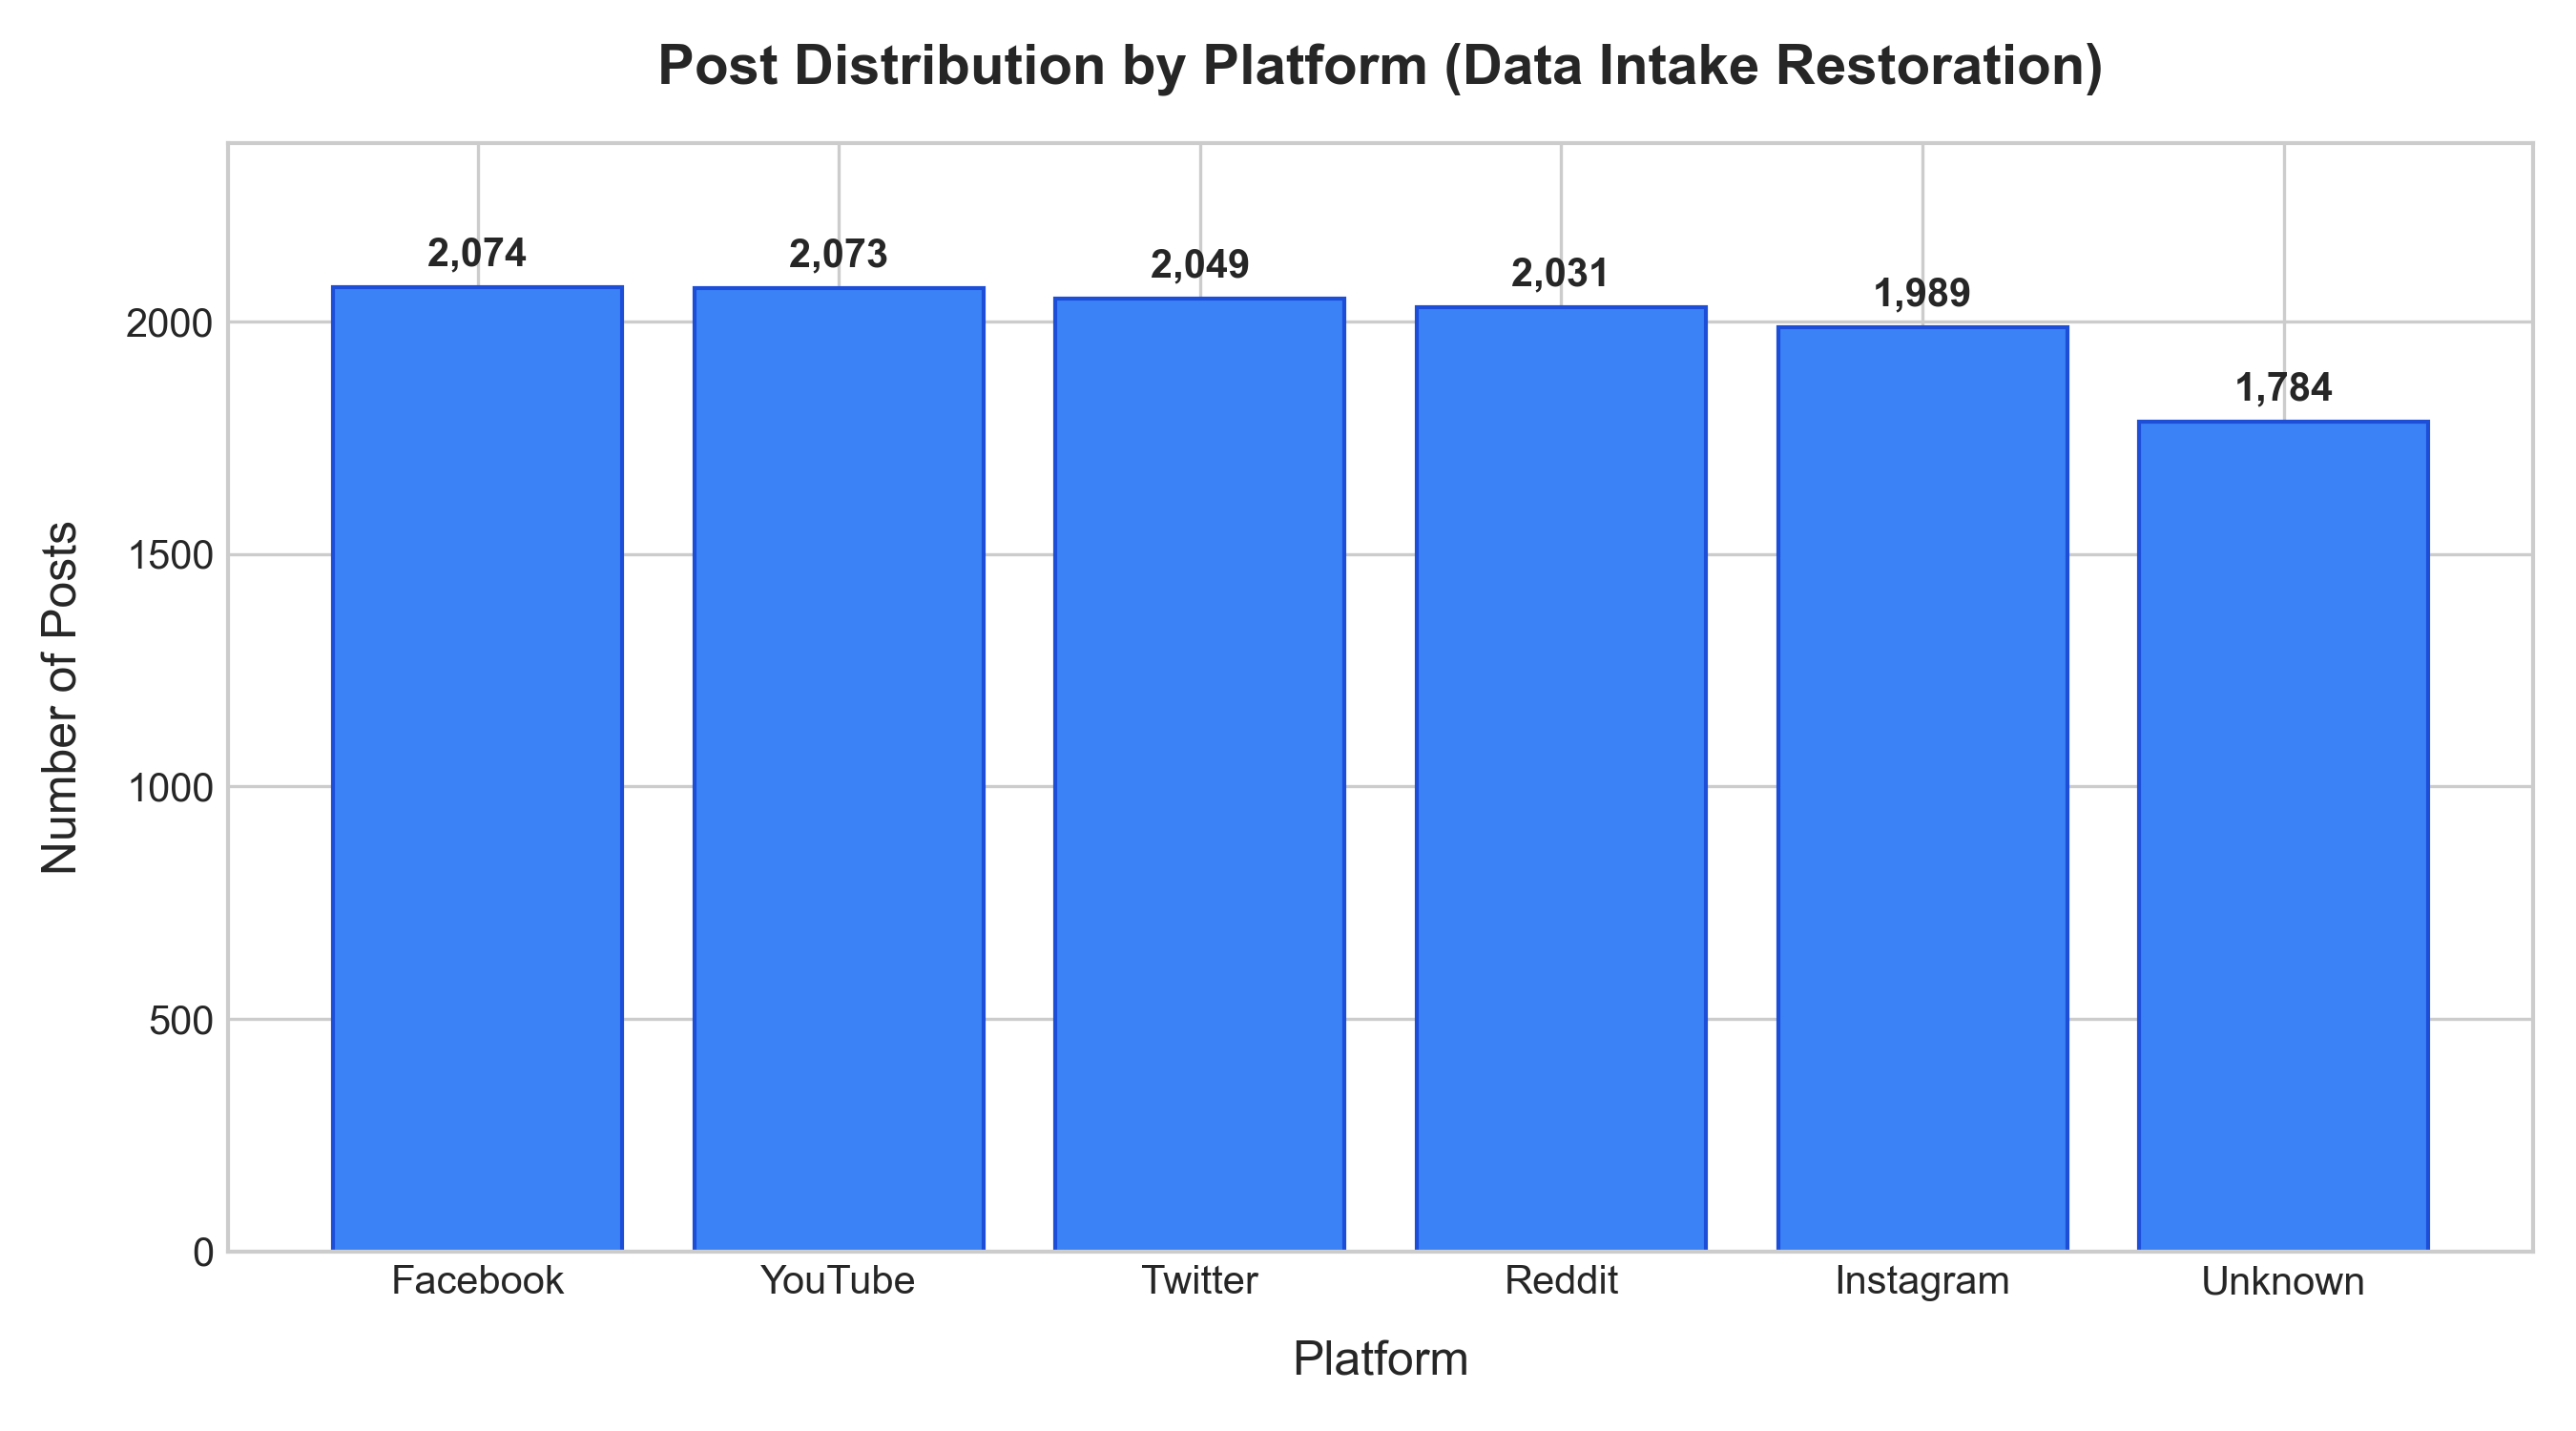

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
counts = merged_df['platform'].value_counts()
bars = ax.bar(counts.index, counts.values, color='#3b82f6', edgecolor='#1d4ed8')
ax.set_title('Post Distribution by Platform (Data Intake Restoration)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Platform', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Posts', fontsize=12, labelpad=10)
for bar in bars:
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y + 30, f"{int(y):,}", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.show()

### 6.2 Average Engagement by Platform
Comparing average interactions (likes, shares, comments) across platforms.

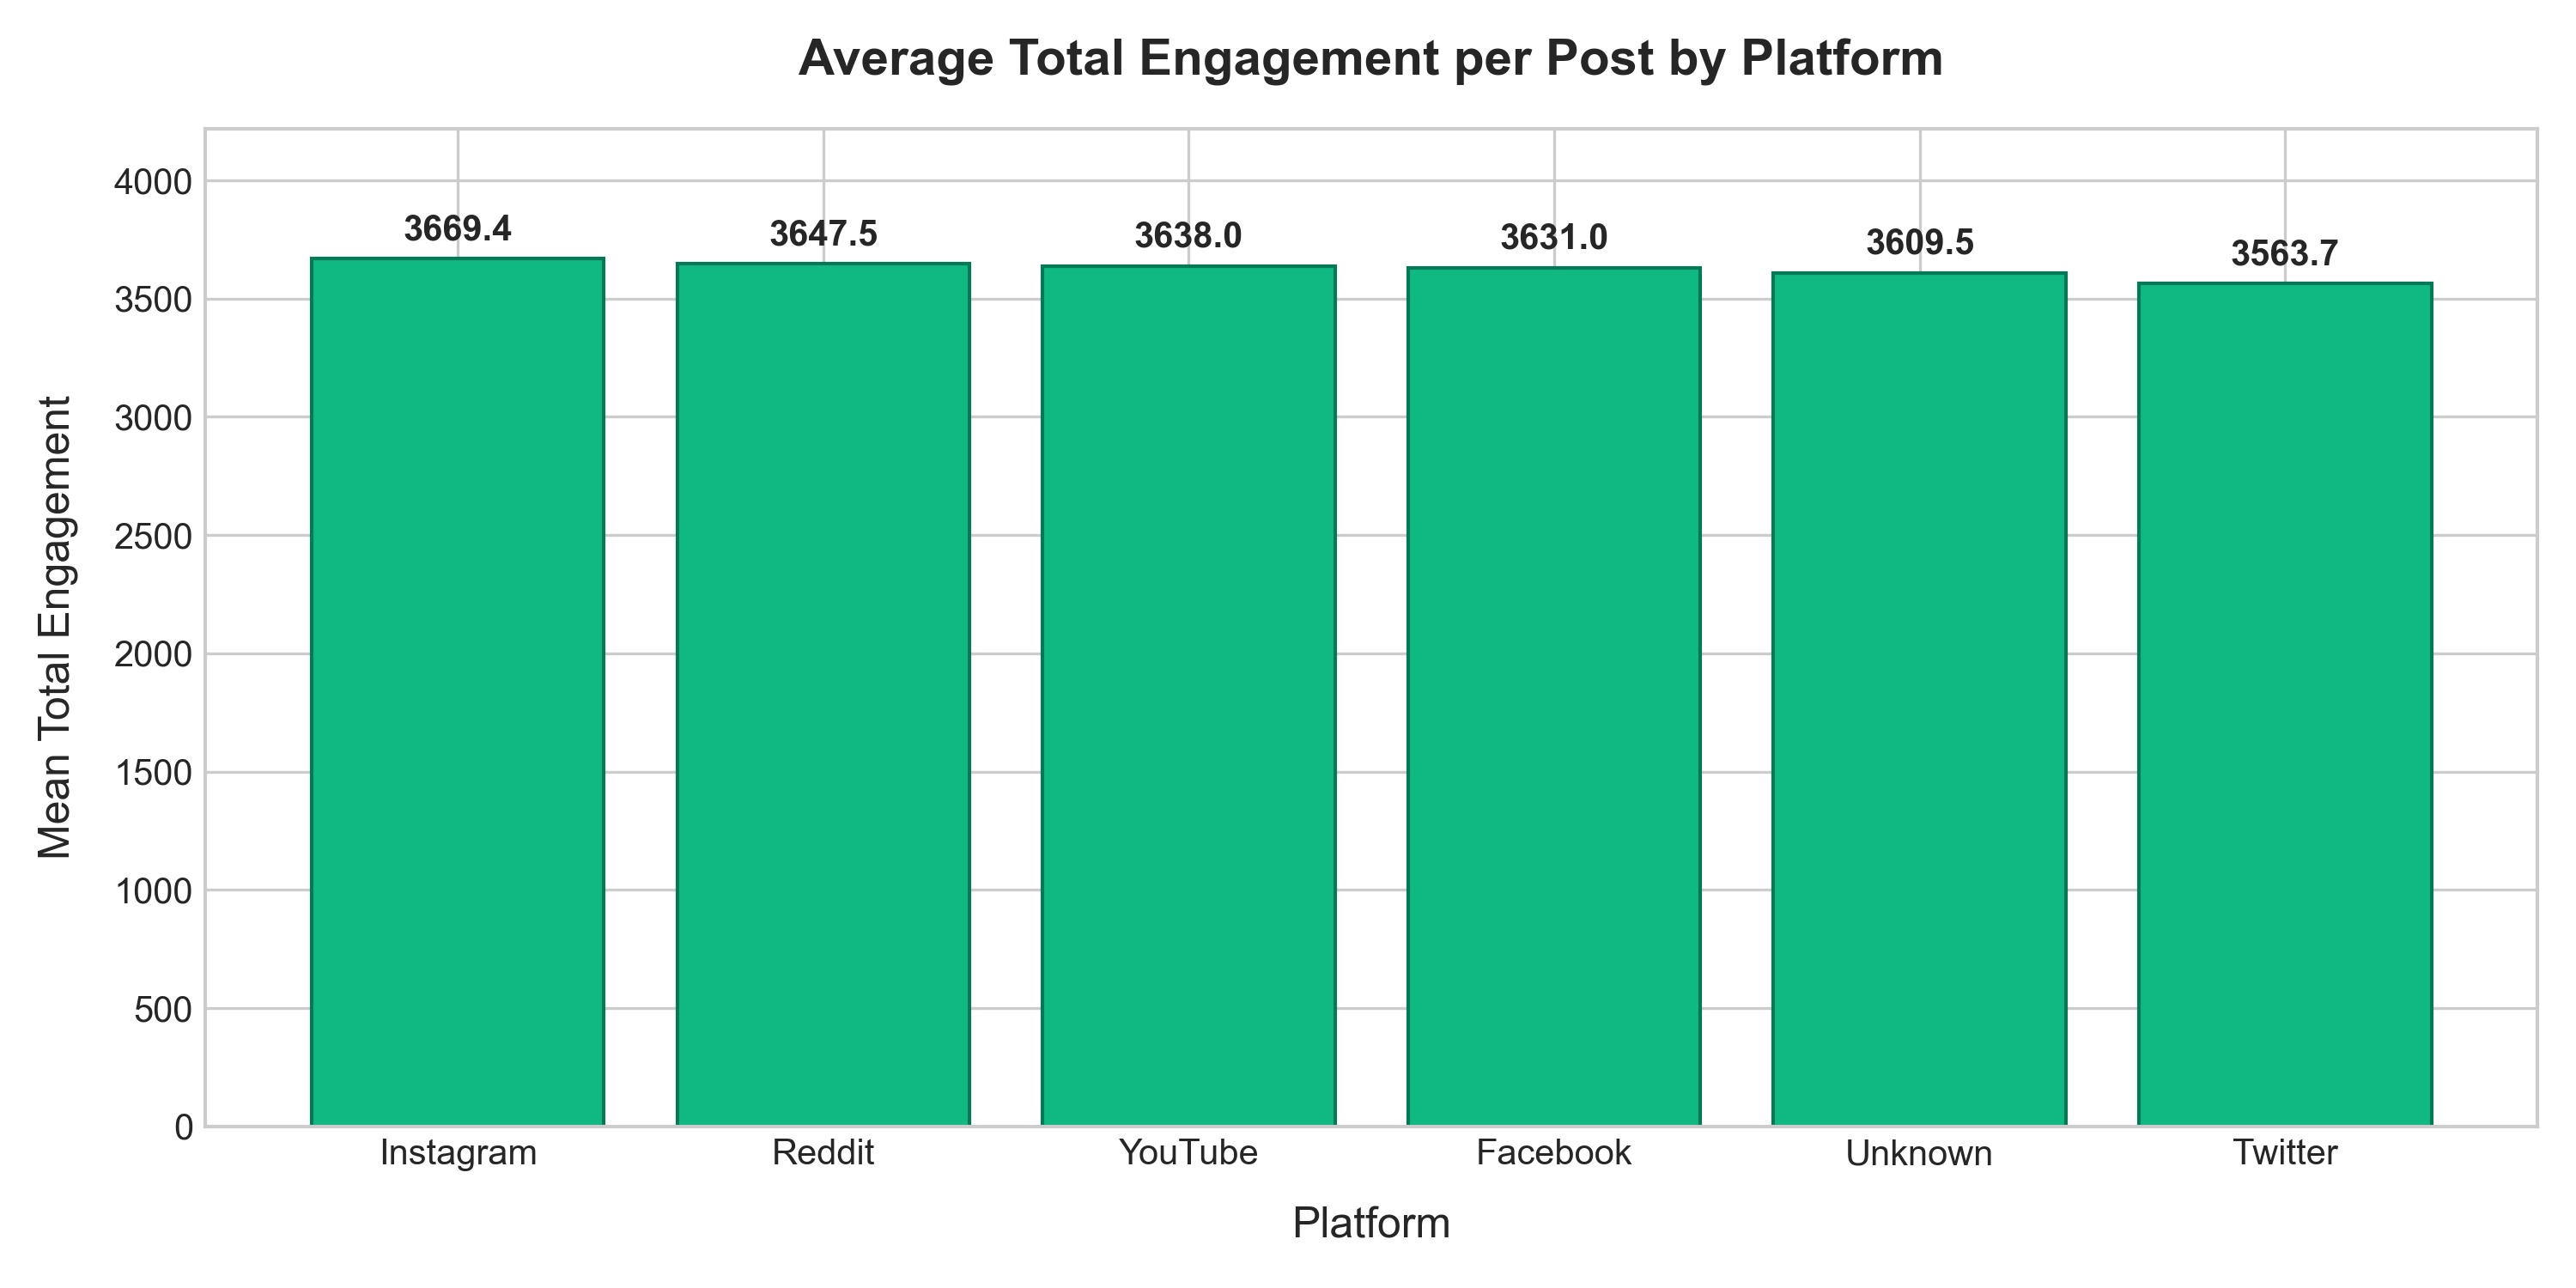

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
plat_eng = merged_df.groupby('platform')['total_engagement'].mean().sort_values(ascending=False)
bars = ax.bar(plat_eng.index, plat_eng.values, color='#10b981', edgecolor='#047857')
ax.set_title('Average Total Engagement per Post by Platform', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Platform', fontsize=12, labelpad=10)
ax.set_ylabel('Mean Total Engagement', fontsize=12, labelpad=10)
for bar in bars:
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y + 50, f"{y:.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, max(plat_eng.values) * 1.15)
plt.tight_layout()
plt.show()

### 6.3 Engagement Rate by Language
Checking how follower conversion differs across user language groups.

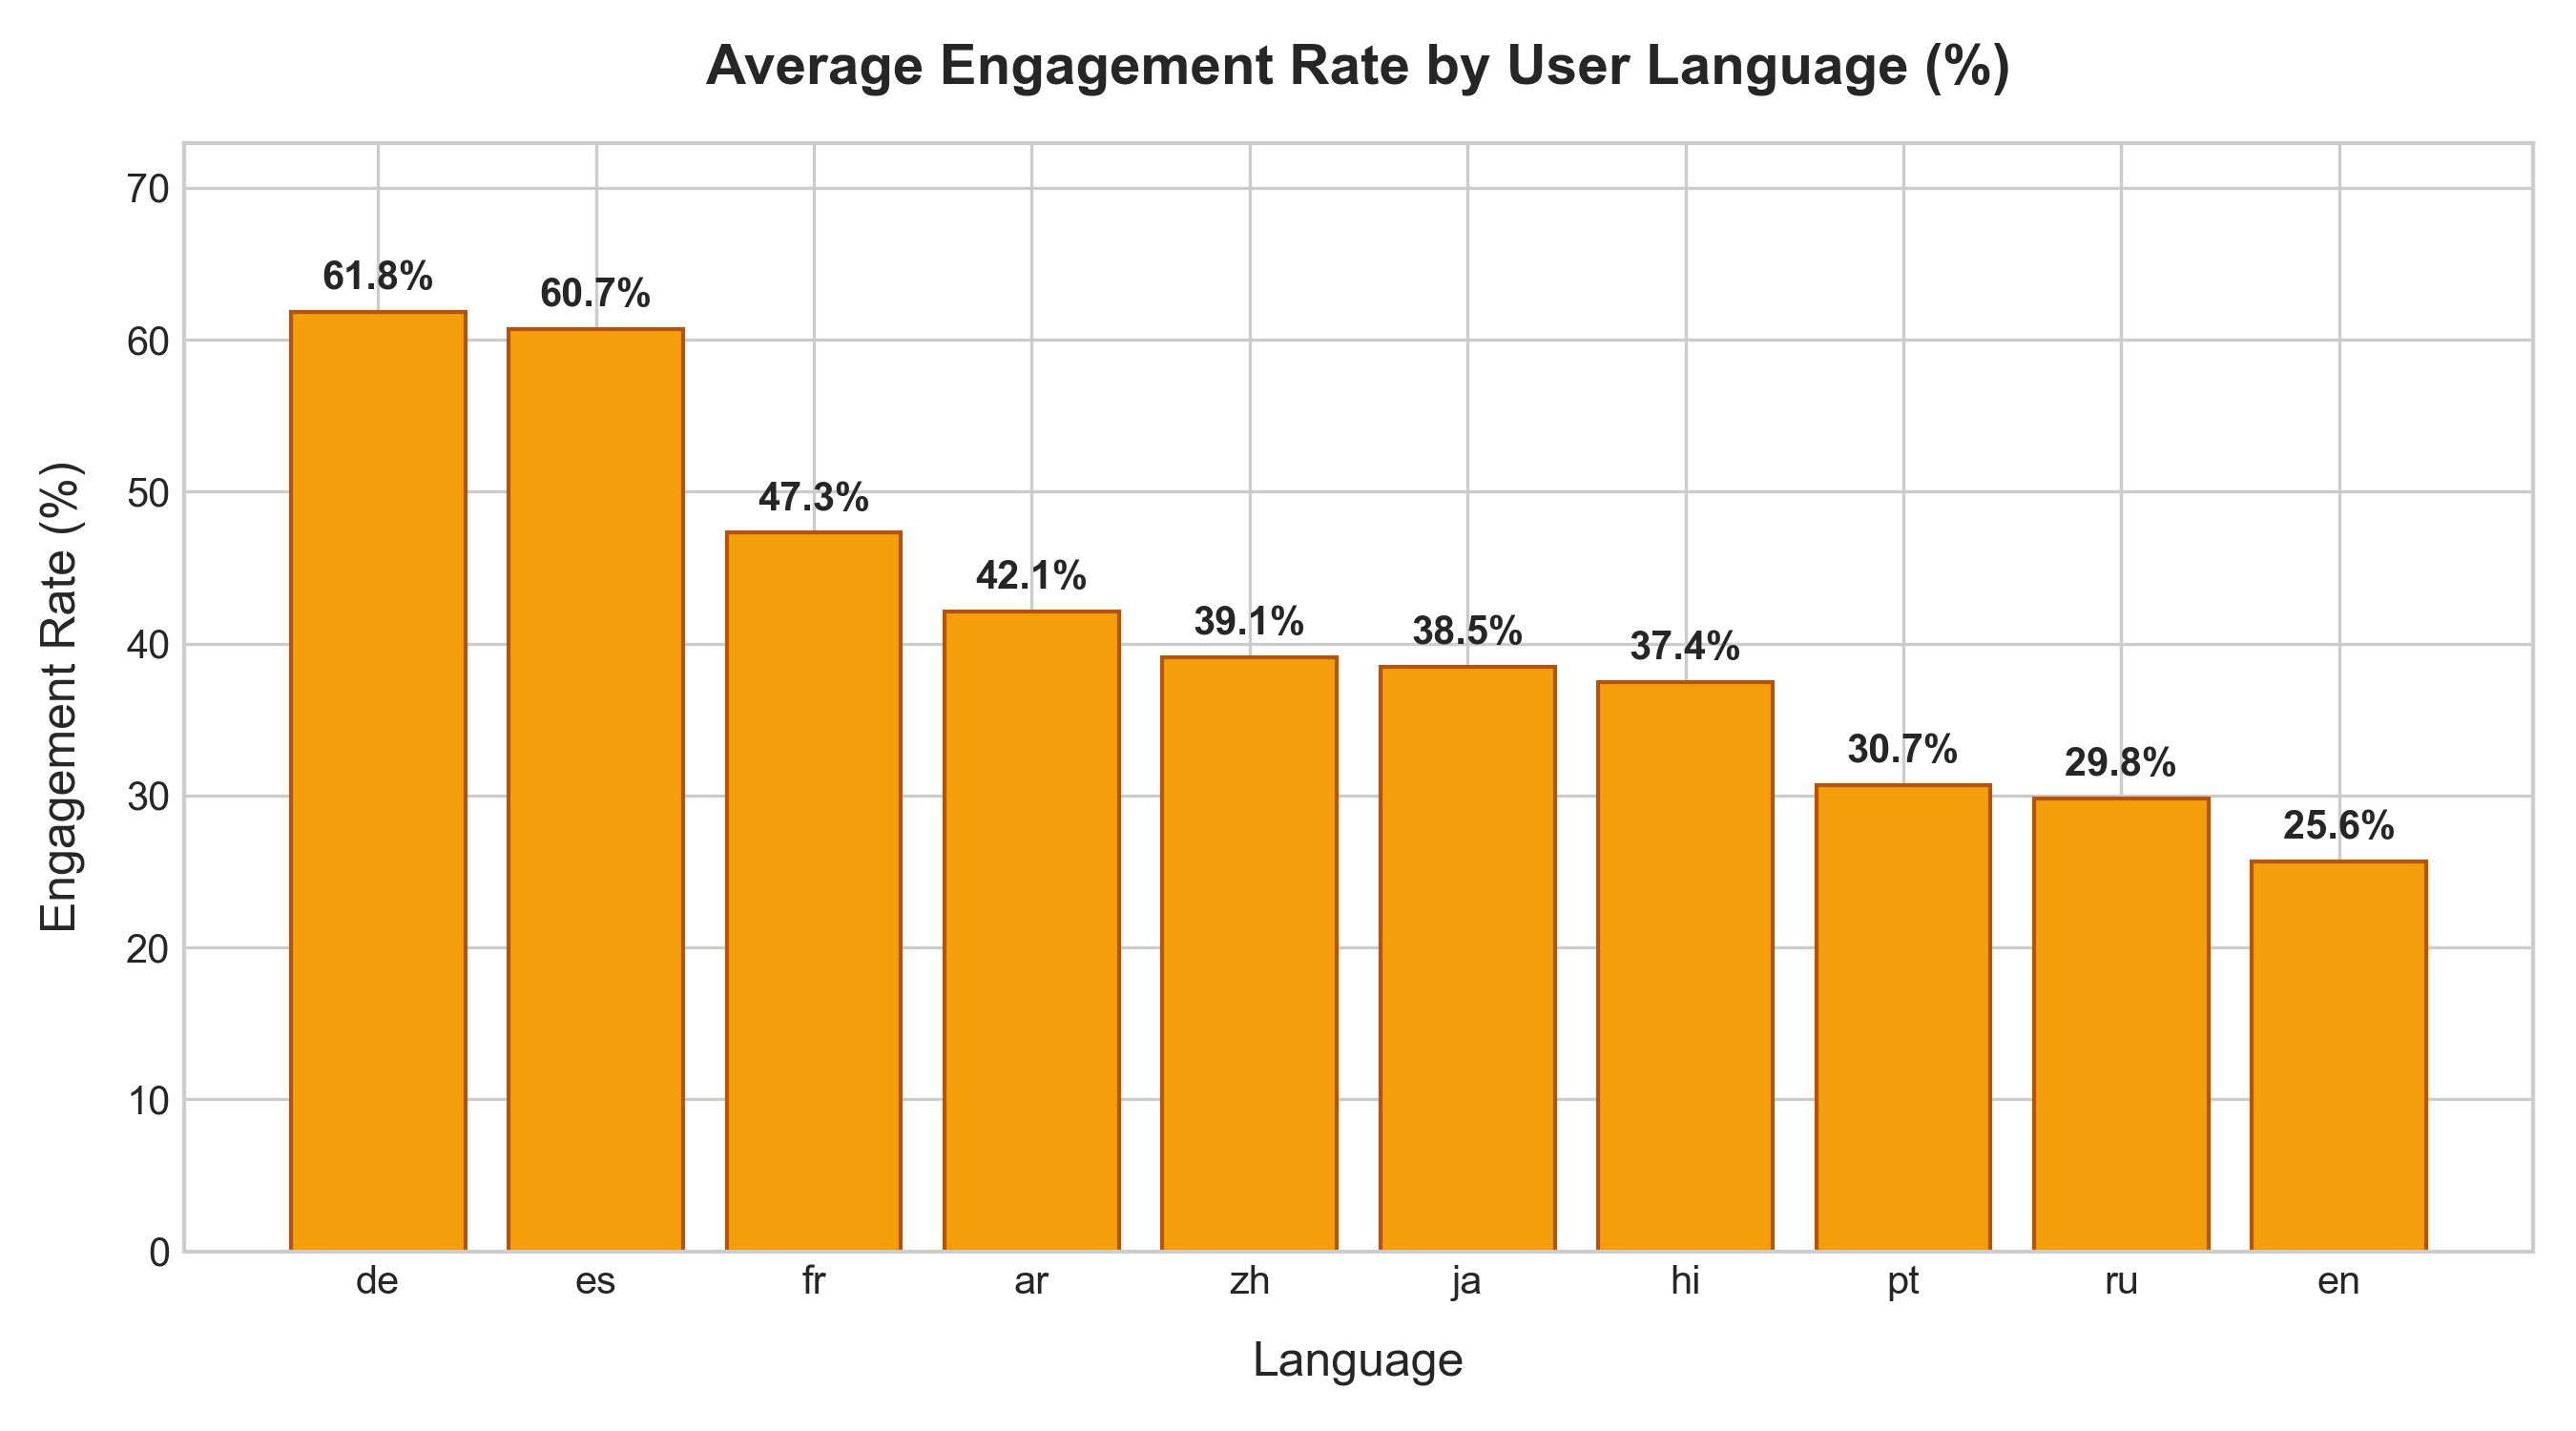

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
lang_eng = (merged_df.groupby('language')['engagement_rate'].mean().sort_values(ascending=False) * 100)
bars = ax.bar(lang_eng.index, lang_eng.values, color='#f59e0b', edgecolor='#b45309')
ax.set_title('Average Engagement Rate by User Language (%)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Language', fontsize=12, labelpad=10)
ax.set_ylabel('Engagement Rate (%)', fontsize=12, labelpad=10)
for bar in bars:
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y + 1, f"{y:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, max(lang_eng.values) * 1.18)
plt.tight_layout()
plt.show()

### 6.4 The Scale Paradox: Follower Count vs. Engagement
Checking correlation to see whether having more followers leads to higher engagement volume or rates.

Correlation (Follower Count vs Raw Engagement Volume): r = -0.0109
Correlation (Follower Count vs Engagement Rate): r = -0.3139


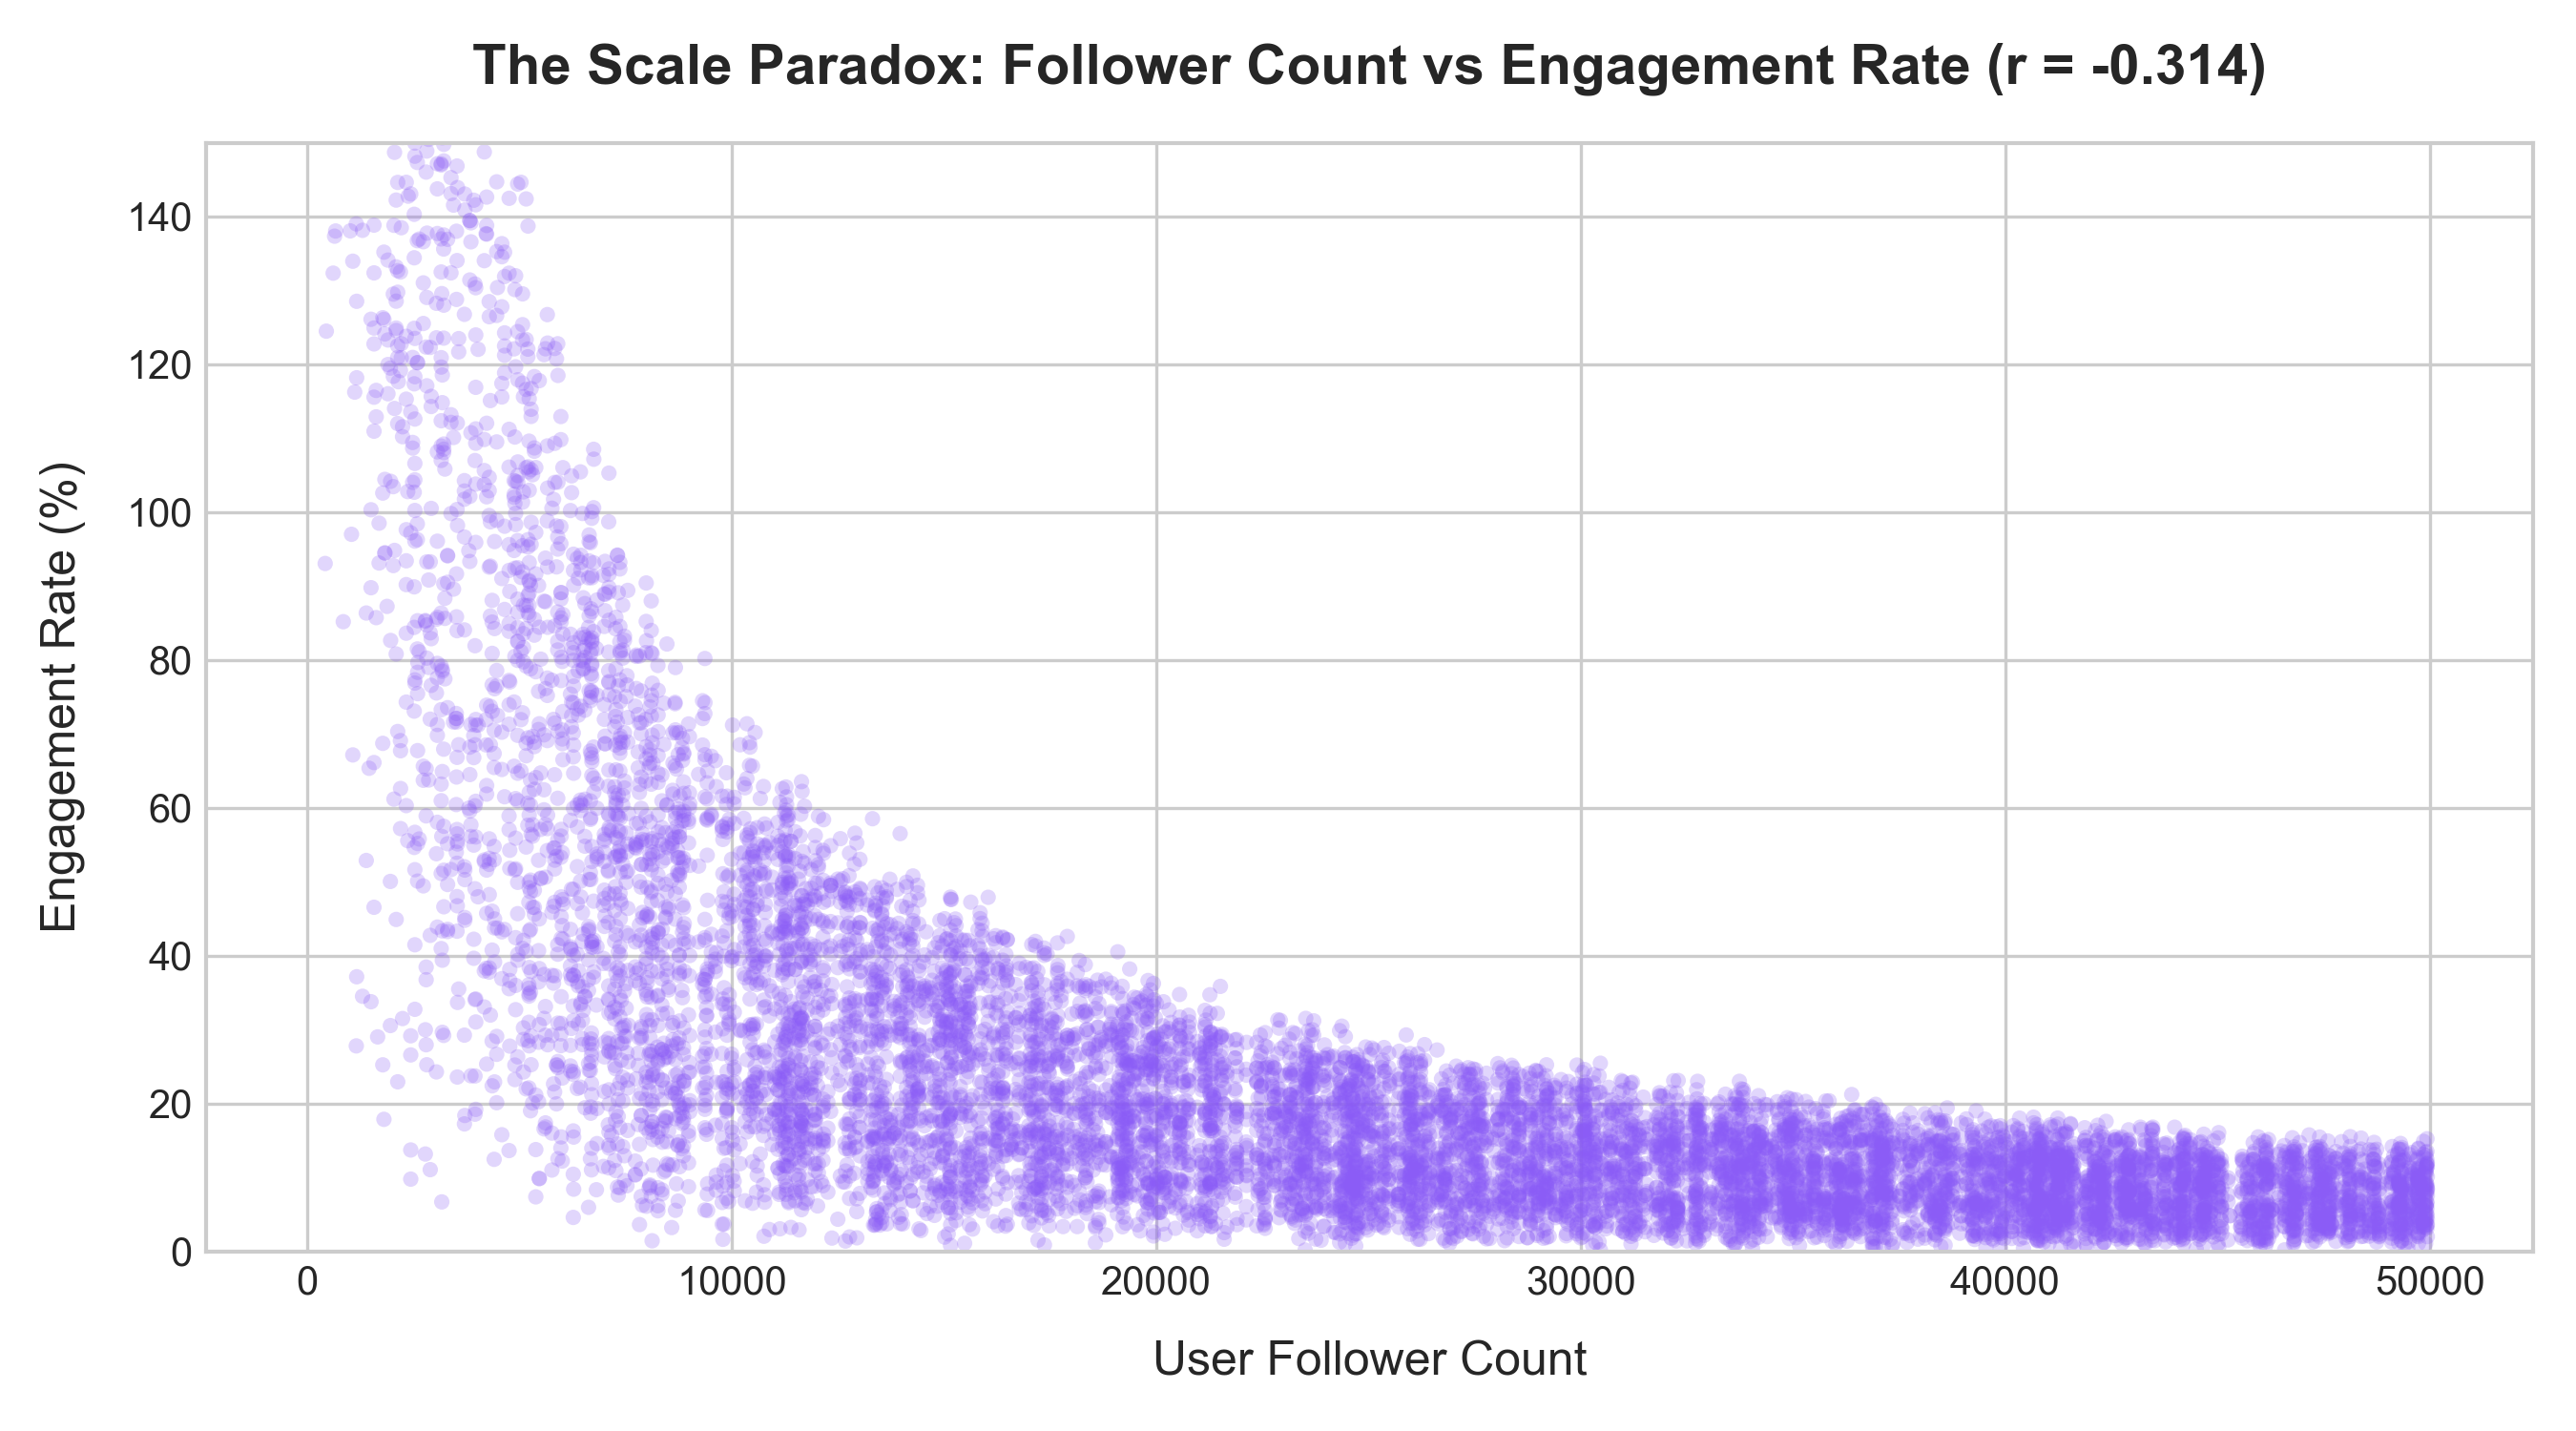

In [9]:
r_vol = merged_df['follower_count'].corr(merged_df['total_engagement'])
r_rate = merged_df['follower_count'].corr(merged_df['engagement_rate'])
print(f"Correlation (Follower Count vs Raw Engagement Volume): r = {r_vol:.4f}")
print(f"Correlation (Follower Count vs Engagement Rate): r = {r_rate:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(merged_df['follower_count'], merged_df['engagement_rate'] * 100, alpha=0.25, color='#8b5cf6', s=15, edgecolors='none')
ax.set_title(f'The Scale Paradox: Follower Count vs Engagement Rate (r = {r_rate:.3f})', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('User Follower Count', fontsize=12, labelpad=10)
ax.set_ylabel('Engagement Rate (%)', fontsize=12, labelpad=10)
ax.set_ylim(0, min(150, (merged_df['engagement_rate'] * 100).quantile(0.999)))
plt.tight_layout()
plt.show()